# **Day 65: Semantic Segmentation and Object Detection**
*Module 10 - Deep Learning Foundations*

Classification answers "what is in this patch?". Many tasks need more:

| Task | Output | Remote sensing examples |
|---|---|---|
| Scene classification | one label per image | EuroSAT land use |
| **Semantic segmentation** | a class for **every pixel** | land-cover maps, flood extent, field boundaries, burnt areas |
| **Object detection** | boxes + classes | ships, vehicles, buildings, trees |
| Instance segmentation | a mask per object | individual building footprints, tree crowns |
| Change detection | per-pixel change between dates | deforestation, urban growth |

> Semantic segmentation gives a class to every pixel of an image; object detection draws boxes around individual objects. U-Net and detection networks are the standard tools.
>
> *Example:* Segmentation produces a flood mask for every pixel of a SAR scene; detection draws a box around each ship in a harbour.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.nn.functional as F, time
from torch.utils.data import DataLoader, TensorDataset
from scipy.ndimage import gaussian_filter, binary_dilation
torch.manual_seed(65); rng = np.random.default_rng(65)

## **1. Synthetic Scenes With Pixel Labels**
4-band (B, G, R, NIR) scenes with four classes: 0 background vegetation, 1 water (rivers/ponds), 2 buildings (small rectangles), 3 roads (thin lines). Buildings and roads are **small and thin**: a realistic class-imbalance challenge.

class frequencies (train pixels): {'vegetation': 0.836, 'water': 0.099, 'building': 0.022, 'road': 0.043}


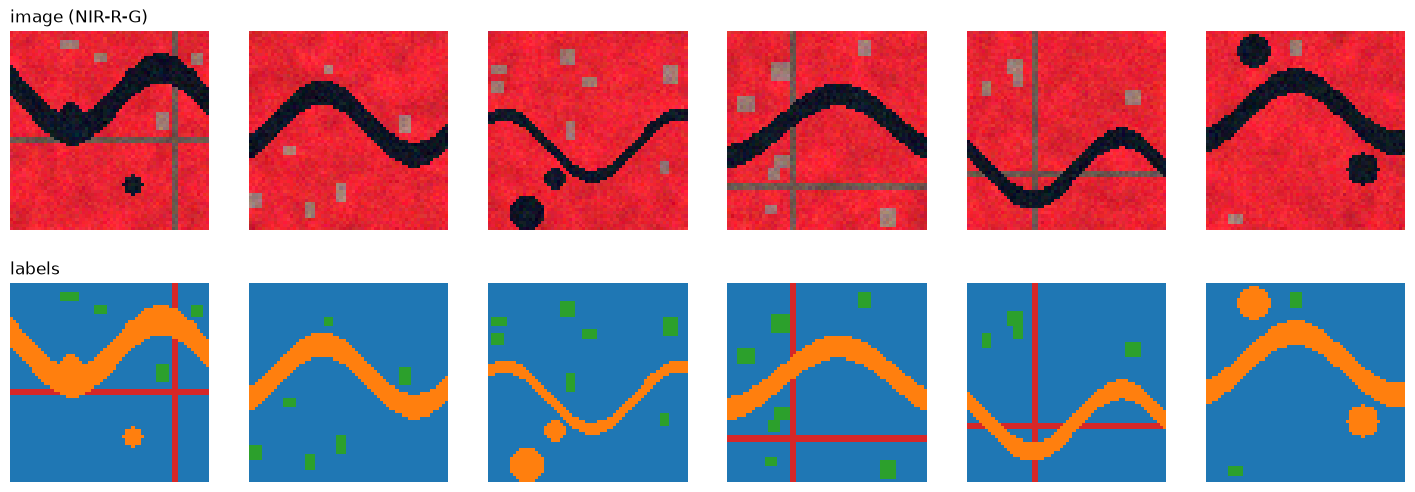

In [2]:
CLASS_NAMES = ["vegetation", "water", "building", "road"]
SPEC = np.array([[0.04, 0.07, 0.05, 0.32], [0.06, 0.05, 0.03, 0.02], [0.16, 0.16, 0.17, 0.22], [0.11, 0.11, 0.12, 0.15]])

def make_scene(size=64, r=rng):
    lab = np.zeros((size, size), np.int64); yy, xx = np.mgrid[0:size, 0:size]
    river = np.abs(yy - (size / 2 + 10 * np.sin(xx / r.uniform(6, 12) + r.uniform(0, 6)) + r.uniform(-15, 15))) < r.uniform(2, 5)
    if r.random() < 0.8: lab[river] = 1                                          # a river in 80% of scenes
    for _ in range(r.integers(0, 3)):
        cy, cx = r.integers(5, size - 5, 2); lab[(yy - cy) ** 2 + (xx - cx) ** 2 < r.uniform(9, 30)] = 1
    if r.random() < 0.8:
        row = r.integers(2, size - 2); lab[row:row + 2, :] = np.where(lab[row:row + 2, :] == 1, 1, 3)
        col = r.integers(2, size - 2); lab[:, col:col + 2] = np.where(lab[:, col:col + 2] == 1, 1, 3)
    for _ in range(r.integers(3, 12)):
        h, w = r.integers(3, 7, 2); y0, x0 = r.integers(0, size - h), r.integers(0, size - w)
        if (lab[y0:y0 + h, x0:x0 + w] == 0).all(): lab[y0:y0 + h, x0:x0 + w] = 2
    img = SPEC[lab].transpose(2, 0, 1) * (1 + gaussian_filter(r.normal(size=(size, size)), 2)[None] * 0.25) + r.normal(0, 0.012, (4, size, size))
    return img.astype(np.float32), lab

def make_set(n, seed):
    r = np.random.default_rng(seed); pairs = [make_scene(64, r) for _ in range(n)]
    return np.stack([p[0] for p in pairs]), np.stack([p[1] for p in pairs])

X_tr, Y_tr = make_set(400, 1); X_va, Y_va = make_set(60, 2); X_te, Y_te = make_set(100, 3)
mean, std = X_tr.mean((0, 2, 3), keepdims=True), X_tr.std((0, 2, 3), keepdims=True)
print("class frequencies (train pixels):", dict(zip(CLASS_NAMES, np.round(np.bincount(Y_tr.ravel()) / Y_tr.size, 3).tolist())))
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for j in range(6):
    axes[0, j].imshow(np.clip(X_tr[j][[3, 2, 1]].transpose(1, 2, 0) / 0.35, 0, 1)); axes[1, j].imshow(Y_tr[j], cmap="tab10", vmin=0, vmax=9)
    axes[0, j].axis("off"); axes[1, j].axis("off")
axes[0, 0].set_title("image (NIR-R-G)", loc="left"); axes[1, 0].set_title("labels", loc="left"); plt.show()

## **2. U-Net From Scratch**
U-Net (Ronneberger et al., 2015): an **encoder** (downsampling, more channels: "what") and a **decoder** (upsampling back to full resolution: "where"), with **skip connections** that copy high-resolution encoder features to the decoder, recovering fine boundaries. Output: one score per class per pixel.

In [3]:
def double_conv(ci, co):
    return nn.Sequential(nn.Conv2d(ci, co, 3, padding=1, bias=False), nn.BatchNorm2d(co), nn.ReLU(inplace=True),
                         nn.Conv2d(co, co, 3, padding=1, bias=False), nn.BatchNorm2d(co), nn.ReLU(inplace=True))

class UNet(nn.Module):
    def __init__(self, in_ch=4, n_classes=4, base=16, skips=True):
        super().__init__(); self.skips = skips
        self.e1, self.e2, self.e3 = double_conv(in_ch, base), double_conv(base, base * 2), double_conv(base * 2, base * 4)
        self.bott = double_conv(base * 4, base * 8)
        self.up3, self.up2, self.up1 = nn.ConvTranspose2d(base * 8, base * 4, 2, 2), nn.ConvTranspose2d(base * 4, base * 2, 2, 2), nn.ConvTranspose2d(base * 2, base, 2, 2)
        m = 2 if skips else 1
        self.d3, self.d2, self.d1 = double_conv(base * 4 * m, base * 4), double_conv(base * 2 * m, base * 2), double_conv(base * m, base)
        self.out = nn.Conv2d(base, n_classes, 1)
    def forward(self, x):
        e1 = self.e1(x); e2 = self.e2(F.max_pool2d(e1, 2)); e3 = self.e3(F.max_pool2d(e2, 2))
        b = self.bott(F.max_pool2d(e3, 2))
        cat = (lambda u, e: torch.cat([u, e], 1)) if self.skips else (lambda u, e: u)
        d3 = self.d3(cat(self.up3(b), e3)); d2 = self.d2(cat(self.up2(d3), e2)); d1 = self.d1(cat(self.up1(d2), e1))
        return self.out(d1)

unet = UNet()
print(f"U-Net parameters: {sum(p.numel() for p in unet.parameters()):,} | output {tuple(unet(torch.randn(2, 4, 64, 64)).shape)} (batch, classes, H, W)")

U-Net parameters: 482,932 | output (2, 4, 64, 64) (batch, classes, H, W)


## **3. Losses and Metrics**
- **Cross-entropy** per pixel, optionally **class-weighted**: frequent background dominates otherwise.
- **Dice loss**: $1 - \frac{2|P\cap G|}{|P|+|G|}$ on soft probabilities; directly optimises overlap; robust to imbalance.
- **IoU** (Jaccard) $=\frac{TP}{TP+FP+FN}$ per class; report **per-class IoU and mean IoU (mIoU)**, plus F1 (= Dice).

In [4]:
def dice_loss(logits, target, eps=1.0):
    p = torch.softmax(logits, 1); oh = F.one_hot(target, logits.shape[1]).permute(0, 3, 1, 2).float()
    inter = (p * oh).sum((0, 2, 3)); denom = p.sum((0, 2, 3)) + oh.sum((0, 2, 3))
    return 1 - ((2 * inter + eps) / (denom + eps)).mean()

def seg_metrics(pred, gt, n_classes=4):
    rows = []
    for k in range(n_classes):
        tp = np.sum((pred == k) & (gt == k)); fp = np.sum((pred == k) & (gt != k)); fn = np.sum((pred != k) & (gt == k))
        rows.append({"class": CLASS_NAMES[k], "IoU": tp / (tp + fp + fn + 1e-9), "F1": 2 * tp / (2 * tp + fp + fn + 1e-9)})
    df = pd.DataFrame(rows).set_index("class"); df.loc["mean"] = df.mean(); return df

## **4. Training**

In [5]:
def train_seg(model, loss_mode="ce+dice", epochs=25, lr=2e-3, seed=0):
    torch.manual_seed(seed)
    dl = DataLoader(TensorDataset(torch.tensor((X_tr - mean) / std), torch.tensor(Y_tr)), batch_size=16, shuffle=True)
    freq = np.bincount(Y_tr.ravel(), minlength=4) / Y_tr.size; w = torch.tensor(1 / np.sqrt(freq), dtype=torch.float32); w /= w.mean()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4); sched = torch.optim.lr_scheduler.OneCycleLR(opt, lr, total_steps=epochs * len(dl))
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            k = np.random.default_rng(ep).integers(4)                                   # rotation augmentation (image AND mask)
            xb, yb = torch.rot90(xb, k, (2, 3)), torch.rot90(yb, k, (1, 2))
            logits = model(xb)
            if loss_mode == "ce": loss = F.cross_entropy(logits, yb)
            elif loss_mode == "weighted ce": loss = F.cross_entropy(logits, yb, weight=w)
            else: loss = F.cross_entropy(logits, yb, weight=w) + dice_loss(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    return model

def predict(model, X):
    model.eval()
    with torch.no_grad(): return model(torch.tensor((X - mean) / std)).argmax(1).numpy()

t0 = time.perf_counter(); unet = train_seg(UNet(), "ce+dice"); print(f"trained in {time.perf_counter() - t0:.0f}s")
P_te = predict(unet, X_te)
seg_metrics(P_te, Y_te).round(3)

trained in 53s


,IoU,F1
class,,
vegetation,1.0,1.0
water,1.0,1.0
building,1.0,1.0
road,1.0,1.0
mean,1.0,1.0


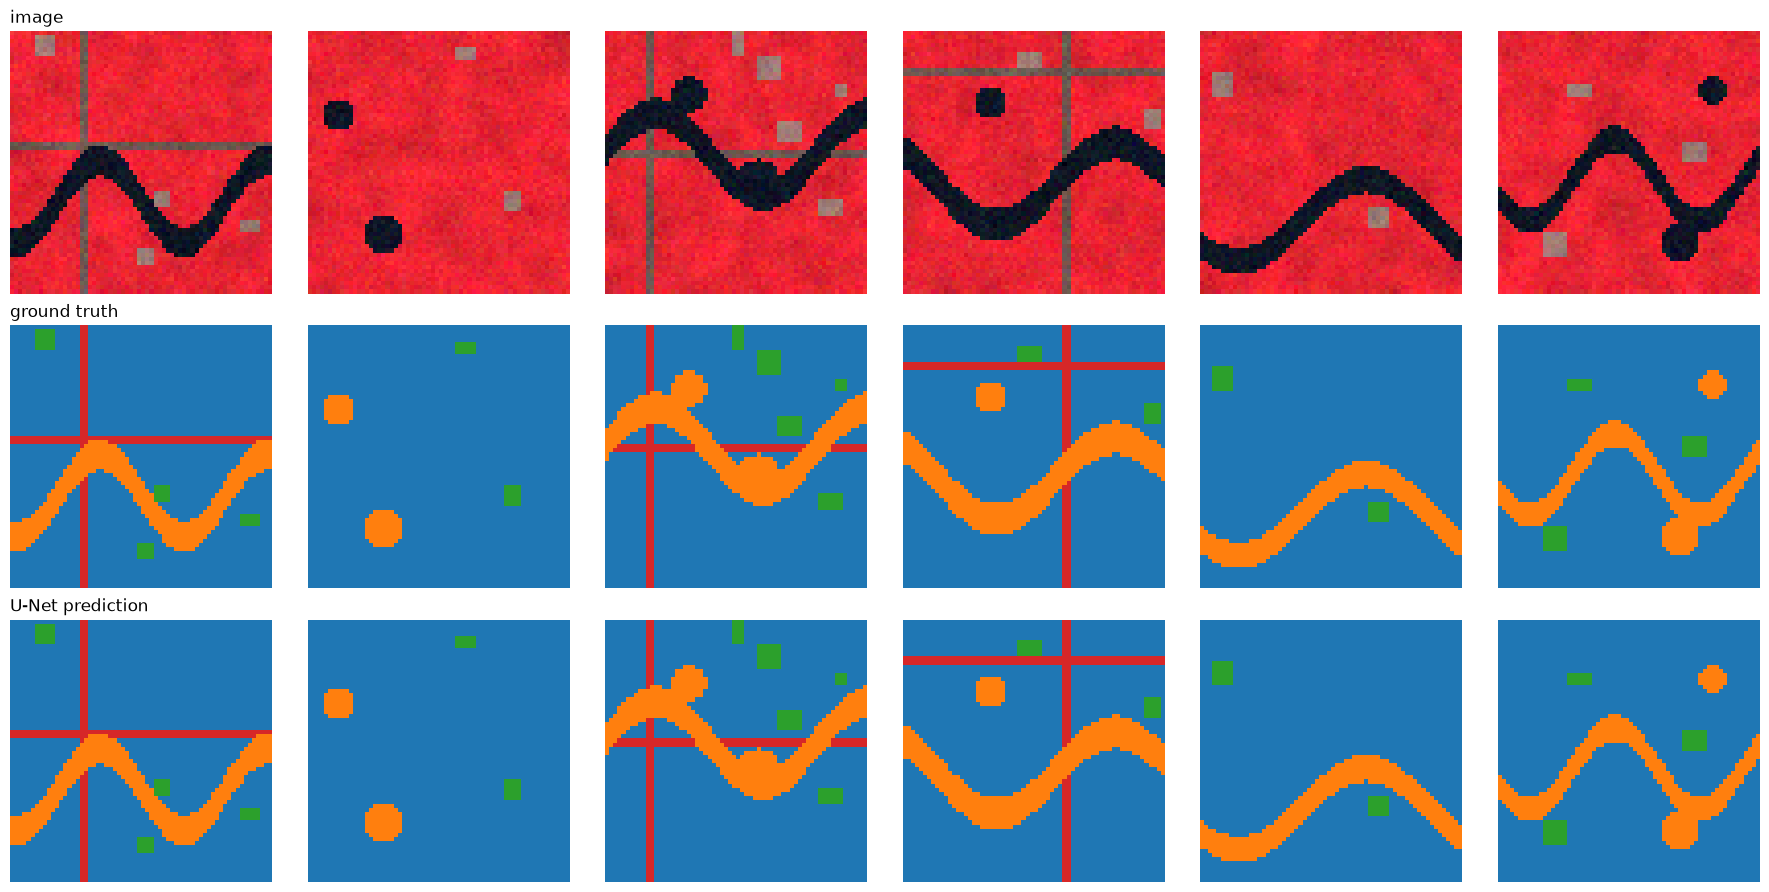

In [6]:
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for j in range(6):
    axes[0, j].imshow(np.clip(X_te[j][[3, 2, 1]].transpose(1, 2, 0) / 0.35, 0, 1)); axes[1, j].imshow(Y_te[j], cmap="tab10", vmin=0, vmax=9)
    axes[2, j].imshow(P_te[j], cmap="tab10", vmin=0, vmax=9)
for ax in axes.ravel(): ax.axis("off")
for i, t in enumerate(["image", "ground truth", "U-Net prediction"]): axes[i, 0].set_title(t, loc="left")
plt.tight_layout(); plt.show()

### Ablation: skip connections and loss functions

In [7]:
rows = {}
for name, model, mode in [("U-Net, CE", UNet(), "ce"), ("U-Net, weighted CE", UNet(), "weighted ce"), ("U-Net, weighted CE + Dice", UNet(), "ce+dice"),
                          ("encoder-decoder WITHOUT skips, CE + Dice", UNet(skips=False), "ce+dice")]:
    m_ = seg_metrics(predict(train_seg(model, mode), X_te), Y_te)
    rows[name] = {"IoU building": m_.loc["building", "IoU"], "IoU road": m_.loc["road", "IoU"], "mIoU": m_.loc["mean", "IoU"]}
pd.DataFrame(rows).T.round(3)

,IoU building,IoU road,mIoU
"U-Net, CE",1.0,0.999,1.000
"U-Net, weighted CE",1.0,1.000,1.000
"U-Net, weighted CE + Dice",1.0,1.000,1.000
"encoder-decoder WITHOUT skips, CE + Dice",0.9,0.981,0.946


Skip connections matter most for small, thin objects (roads, buildings); weighting and Dice help the rare classes.

## **5. Predicting a Large Scene by Tiling**
Real scenes are thousands of pixels wide. Predict **overlapping tiles** and average (or keep the centre of each tile) to avoid edge artefacts.

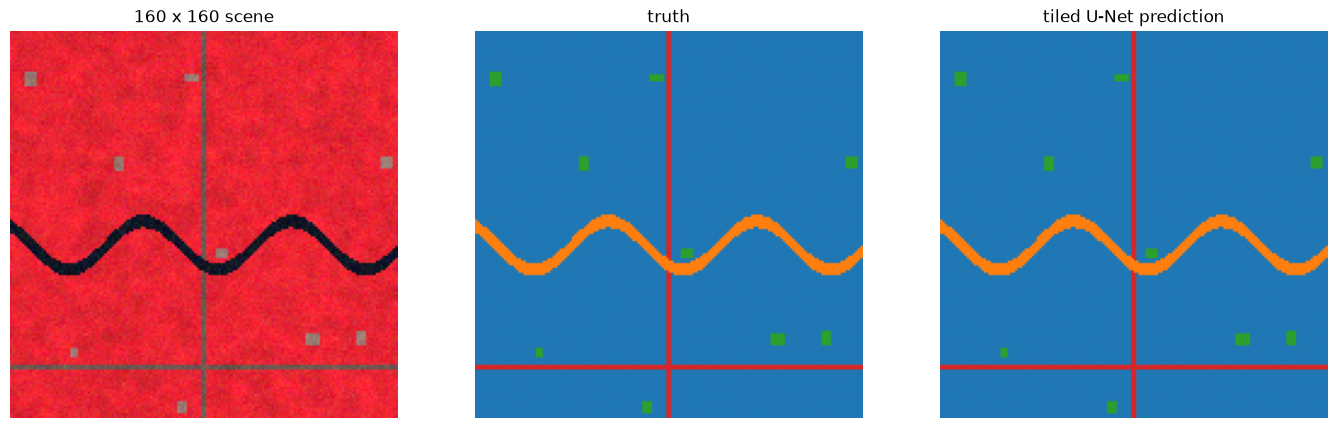

large-scene mIoU: 1.0


In [8]:
def predict_large(model, image, tile=64, stride=48, n_classes=4):
    C, H, W = image.shape; probs = np.zeros((n_classes, H, W)); counts = np.zeros((H, W))
    ys = list(range(0, H - tile + 1, stride)) + [H - tile]; xs = list(range(0, W - tile + 1, stride)) + [W - tile]
    weight = np.outer(np.hanning(tile) + 0.1, np.hanning(tile) + 0.1)                     # down-weight tile borders
    model.eval()
    with torch.no_grad():
        for y0 in sorted(set(ys)):
            for x0 in sorted(set(xs)):
                t = torch.tensor(((image[:, y0:y0 + tile, x0:x0 + tile] - mean[0]) / std[0])[None])
                probs[:, y0:y0 + tile, x0:x0 + tile] += torch.softmax(model(t), 1)[0].numpy() * weight; counts[y0:y0 + tile, x0:x0 + tile] += weight
    return (probs / counts).argmax(0)

big_r = np.random.default_rng(7); big_img, big_lab = make_scene(160, big_r)
big_pred = predict_large(unet, big_img)
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
axes[0].imshow(np.clip(big_img[[3, 2, 1]].transpose(1, 2, 0) / 0.35, 0, 1)); axes[1].imshow(big_lab, cmap="tab10", vmin=0, vmax=9); axes[2].imshow(big_pred, cmap="tab10", vmin=0, vmax=9)
for ax, t in zip(axes, ["160 x 160 scene", "truth", "tiled U-Net prediction"]): ax.set_title(t); ax.axis("off")
plt.show(); print("large-scene mIoU:", round(seg_metrics(big_pred, big_lab).loc["mean", "IoU"], 3))

## **6. Object Detection Concepts**
A detector outputs boxes $(x_1, y_1, x_2, y_2)$, a class and a confidence score.
- **IoU of boxes** decides whether a prediction matches a ground-truth object (typically IoU >= 0.5).
- **Anchors**: predefined boxes of several sizes/aspect ratios; the network predicts offsets and objectness.
- **Non-maximum suppression (NMS)**: remove duplicate detections of the same object.
- **mAP** (mean average precision over classes and IoU thresholds) is the standard metric.
- Families: two-stage (**Faster R-CNN**: region proposals then classification), one-stage (**YOLO**, RetinaNet with focal loss), and transformer-based (DETR). Oriented boxes are common for ships and vehicles in aerial imagery.

our NMS keeps: [3, 4, 6, 7, 8] | torchvision.ops.nms keeps: [3, 4, 6, 7, 8]


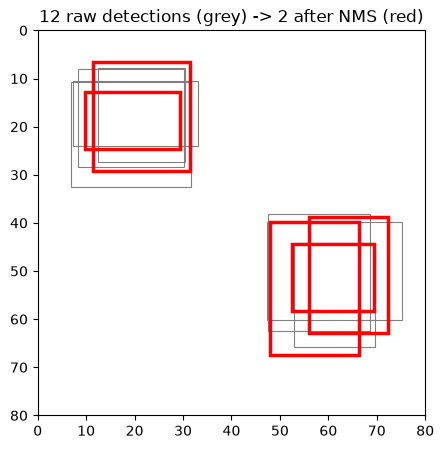

In [9]:
def box_iou(a, b):
    x1, y1 = np.maximum(a[0], b[0]), np.maximum(a[1], b[1]); x2, y2 = np.minimum(a[2], b[2]), np.minimum(a[3], b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1); area = lambda c: (c[2] - c[0]) * (c[3] - c[1])
    return inter / (area(a) + area(b) - inter)

def nms(boxes, scores, iou_thr=0.5):
    order = np.argsort(scores)[::-1]; keep = []
    while len(order):
        i = order[0]; keep.append(i)
        order = np.array([j for j in order[1:] if box_iou(boxes[i], boxes[j]) < iou_thr])
    return keep

true_boxes = np.array([[10, 10, 30, 28], [50, 40, 70, 62]])
cand = np.vstack([b + rng.normal(0, 2.5, (6, 4)) for b in true_boxes]); scores = rng.uniform(0.5, 1, len(cand))
kept = nms(cand, scores)
import torchvision
print("our NMS keeps:", sorted(int(k) for k in kept), "| torchvision.ops.nms keeps:", sorted(torchvision.ops.nms(torch.tensor(cand, dtype=torch.float32), torch.tensor(scores, dtype=torch.float32), 0.5).tolist()))
fig, ax = plt.subplots(figsize=(5, 5)); ax.set_xlim(0, 80); ax.set_ylim(80, 0)
for b in cand: ax.add_patch(plt.Rectangle(b[:2], b[2] - b[0], b[3] - b[1], fill=False, ec="grey", lw=0.8))
for i in kept: ax.add_patch(plt.Rectangle(cand[i][:2], cand[i][2] - cand[i][0], cand[i][3] - cand[i][1], fill=False, ec="r", lw=2.5))
ax.set_title("12 raw detections (grey) -> 2 after NMS (red)"); plt.show()

### Using a torchvision detector (API)

In [10]:
det = torchvision.models.detection.fasterrcnn_mobilenet_v3_large_fpn(weights=None, weights_backbone=None, num_classes=3)   # pretrained: weights="DEFAULT"
det.eval()
with torch.no_grad(): out = det([torch.rand(3, 256, 256)])
print("detector output keys:", list(out[0].keys()), "| (untrained, so detections are meaningless)")
print("training input format: images = [tensor(C,H,W)], targets = [{'boxes': FloatTensor[N, 4], 'labels': Int64Tensor[N]}]")

detector output keys: ['boxes', 'labels', 'scores'] | (untrained, so detections are meaningless)
training input format: images = [tensor(C,H,W)], targets = [{'boxes': FloatTensor[N, 4], 'labels': Int64Tensor[N]}]


# **Part 2: Going Deeper**

### Boundary errors dominate
Most segmentation errors sit on object **edges** (mixed pixels, label imprecision). Evaluating separately on a boundary band shows this, and **boundary-aware** metrics/losses are used for field and building delineation.

In [11]:
gt, pr = Y_te, P_te
edges = np.zeros_like(gt, bool)
for i in range(len(gt)):
    for k in range(4):
        m_k = gt[i] == k; edges[i] |= binary_dilation(m_k, iterations=1) & ~m_k
print(f"pixel accuracy on boundary pixels {np.mean(pr[edges] == gt[edges]):.3f} vs interior {np.mean(pr[~edges] == gt[~edges]):.3f} "
      f"(boundary = {edges.mean():.1%} of pixels)")

pixel accuracy on boundary pixels 1.000 vs interior 1.000 (boundary = 17.2% of pixels)


### Upsampling options
Transposed convolutions (learned, can create checkerboard artefacts), bilinear upsampling + convolution (smooth, common), pixel shuffle (sub-pixel convolution). Architectures beyond U-Net: DeepLabv3+ (atrous spatial pyramid pooling), SegFormer / Mask2Former (transformers), and promptable foundation models such as **SAM** (Segment Anything) adapted to remote sensing.

## **Practice Problems**
1. Report per-class IoU for the model trained with plain CE. Which class suffers most?
2. Change the tiling stride to 64 (no overlap) and compare the large-scene mIoU and the visible seams.
3. Implement **focal loss** $-(1-p_t)^\gamma\log p_t$ for segmentation and compare building/road IoU with weighted CE.
4. *(Advanced)* Compute object-level metrics for buildings: connected components in prediction and truth, match by IoU >= 0.5, report precision and recall of buildings.

In [12]:
# Solution 1
print(seg_metrics(predict(train_seg(UNet(), "ce"), X_te), Y_te).round(3))
# Solution 2
print("no-overlap tiling mIoU:", round(seg_metrics(predict_large(unet, big_img, stride=64), big_lab).loc["mean", "IoU"], 3))
# Solution 3
def focal_loss(logits, target, gamma=2.0):
    logp = F.log_softmax(logits, 1); logpt = logp.gather(1, target[:, None])[:, 0]
    return (-(1 - logpt.exp()) ** gamma * logpt).mean()
torch.manual_seed(0); fm = UNet(); dl = DataLoader(TensorDataset(torch.tensor((X_tr - mean) / std), torch.tensor(Y_tr)), batch_size=16, shuffle=True)
opt = torch.optim.AdamW(fm.parameters(), 2e-3)
for ep in range(25):
    fm.train()
    for xb, yb in dl: opt.zero_grad(); focal_loss(fm(xb), yb).backward(); opt.step()
print(seg_metrics(predict(fm, X_te), Y_te).loc[["building", "road", "mean"]].round(3))
# Solution 4
from scipy.ndimage import label as cc_label
tp = fp = fn = 0
for i in range(len(Y_te)):
    g, ng = cc_label(Y_te[i] == 2); p, npr = cc_label(P_te[i] == 2); matched = set()
    for a in range(1, npr + 1):
        pa = p == a; best = 0
        for b in range(1, ng + 1):
            gb = g == b; iou = np.sum(pa & gb) / np.sum(pa | gb)
            if iou >= 0.5 and b not in matched: best = b; break
        if best: matched.add(best); tp += 1
        else: fp += 1
    fn += ng - len(matched)
print(f"building objects: precision {tp / (tp + fp):.3f}, recall {tp / (tp + fn):.3f}")

              IoU     F1
class                   
vegetation  1.000  1.000
water       1.000  1.000
building    0.999  0.999
road        0.999  1.000
mean        1.000  1.000
no-overlap tiling mIoU: 1.0


          IoU   F1
class             
building  1.0  1.0
road      1.0  1.0
mean      1.0  1.0
building objects: precision 1.000, recall 1.000


## **Key References**
- Long, J., Shelhamer, E., & Darrell, T. (2015). Fully convolutional networks for semantic segmentation. *CVPR 2015*.
- Ronneberger, O., Fischer, P., & Brox, T. (2015). U-Net: Convolutional networks for biomedical image segmentation. *MICCAI 2015*.
- Chen, L.-C., Zhu, Y., Papandreou, G., Schroff, F., & Adam, H. (2018). Encoder-decoder with atrous separable convolution for semantic image segmentation. *ECCV 2018* (DeepLabv3+).
- Ren, S., He, K., Girshick, R., & Sun, J. (2015). Faster R-CNN: Towards real-time object detection with region proposal networks. *NeurIPS 28*.
- Redmon, J., Divvala, S., Girshick, R., & Farhadi, A. (2016). You only look once: Unified, real-time object detection. *CVPR 2016*.
- Lin, T.-Y., Goyal, P., Girshick, R., He, K., & Dollar, P. (2017). Focal loss for dense object detection. *ICCV 2017*.
- Kirillov, A. et al. (2023). Segment anything. *ICCV 2023*.